In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np
import os



 Starting Analysis for: NewspaperData.csv ---
Using X='daily', Y='sunday'

Model Evaluation (Test Set): R-squared = 0.7978, RMSE = 99.64


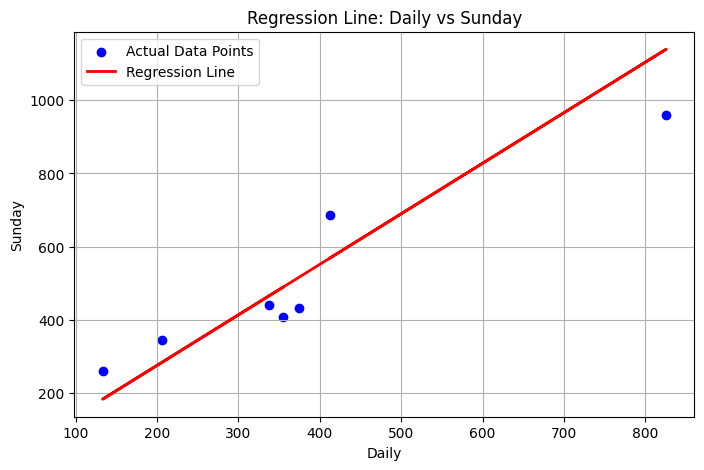


 Starting Analysis for: delivery_time.csv ---
Using X='sorting time', Y='delivery time'

Model Evaluation (Test Set): R-squared = -1.0208, RMSE = 3.75


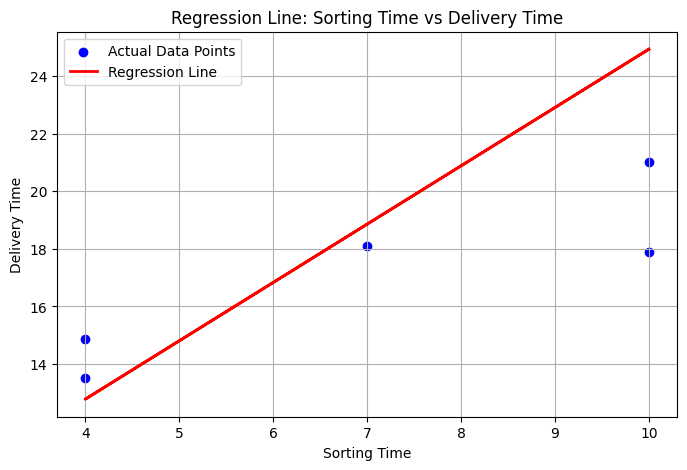


 Starting Analysis for: WC_AT.csv ---
Using X='waist', Y='at'

Model Evaluation (Test Set): R-squared = 0.5047, RMSE = 42.01


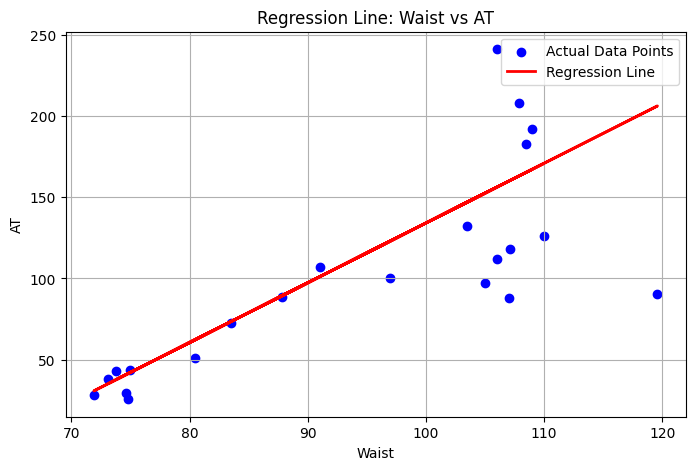

In [25]:


def simple_linear_regression(file_name, independent_var_input, dependent_var_input):
    
    print(f"\n Starting Analysis for: {file_name} ---")
    
    # 1. Load Data
    if not os.path.exists(file_name):
        print(f"Error: {file_name} not found.")
        return
    df = pd.read_csv(file_name)

    # Standardize column names to lowercase to avoid KeyErrors
    df.columns = df.columns.str.lower().str.strip()
    
    independent_var = independent_var_input.lower()
    dependent_var = dependent_var_input.lower()

    print(f"Using X='{independent_var}', Y='{dependent_var}'")

    # 2. Define Variables 
    X = df[[independent_var]] 
    y = df[dependent_var]
    
    # 3. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Build and Train Model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # 5. Make Predictions
    y_pred = model.predict(X_test)

    # 6. Evaluate
    r2 = metrics.r2_score(y_test, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    print(f"\nModel Evaluation (Test Set): R-squared = {r2:.4f}, RMSE = {rmse:.2f}")

    # 7. Plot the Regression Line (Simple style as requested)
    plt.figure(figsize=(8, 5))
    plt.scatter(X_test, y_test, color='blue', label='Actual Data Points')
    plt.plot(X_test, y_pred, color='red', label='Regression Line', linewidth=2)
    
    plt.title(f'Regression Line: {independent_var_input} vs {dependent_var_input}')
    plt.xlabel(independent_var_input)
    plt.ylabel(dependent_var_input)
    plt.legend()
    plt.grid(True)
    plt.show()

# 1. NewspaperData.csv
simple_linear_regression(
    file_name='NewspaperData.csv', 
    independent_var_input='Daily', 
    dependent_var_input='Sunday'
)

# 2. delivery_time.csv
simple_linear_regression(
    file_name='delivery_time.csv', 
    independent_var_input='Sorting Time', 
    dependent_var_input='Delivery Time'
)

# 3. WC_AT.csv
simple_linear_regression(
    file_name='WC_AT.csv', 
    independent_var_input='Waist', 
    dependent_var_input='AT'
)


In [26]:
df = pd.read_csv("TVMarketing.csv")

In [27]:
df.head()
df.tail()
df.info()
df.describe()
df.isna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


,TV,Sales
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
195,False,False
196,False,False
197,False,False
198,False,False


In [28]:
X = df[['TV']]
y = df[['Sales']] 


In [29]:
from sklearn.model_selection import train_test_split
# split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=123456)

In [30]:
from sklearn.linear_model import LinearRegression
# create a model
model = LinearRegression()
# train the model using the x and y
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
# Use the trained model to predict y values (Sales)
y_pred = model.predict(X)

print("Predictions generated.")


Predictions generated.


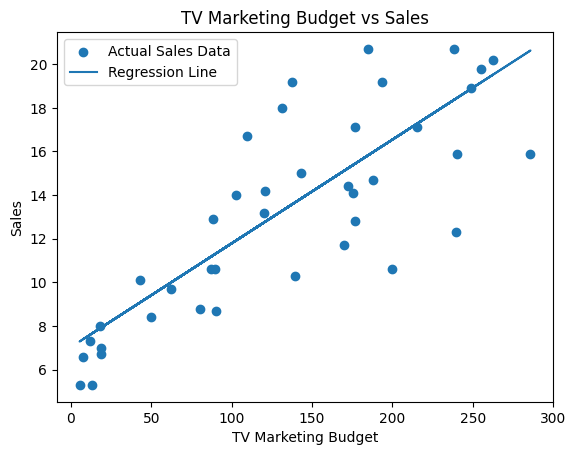

In [37]:
plt.scatter(x_test['TV'], y_test, label='Actual Sales Data')
plt.plot(x_test['TV'], model.predict(x_test), label='Regression Line')

plt.title('TV Marketing Budget vs Sales')
plt.xlabel('TV Marketing Budget')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [39]:
print(f"Intercept (c): {model.intercept_[0]:.4f}")
print(f"Coefficient (m): {model.coef_[0][0]:.4f}")

# Interpretation: For every 1 unit increase in TV Budget, sales increase by 'm' units.


Intercept (c): 7.0326
Coefficient (m): 0.0475


Que. 3
You own an ice cream business and you would like to create a model that could predict the daily revenue in dollars based on the outside air temperature (degC). Build Linear Regression Model and plot regression line.

Dataset : IceCreamData.csv


In [40]:
df = pd.read_csv('IceCreamData.csv')

In [41]:
df.head()
df.tail()
df.isna()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


In [42]:
X = df[['Temperature']]
y = df['Revenue'] 

In [43]:
from sklearn.model_selection import train_test_split
x_train ,x_test, y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [44]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

Mean Squared Error (MSE): 652.52
R-squared Score (R2): 0.9772


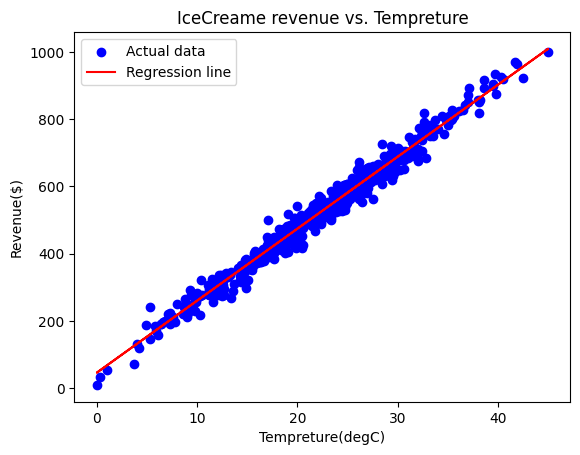

In [46]:
plt.scatter(X,y, color = 'blue', label ='Actual data')
plt.plot(X, model.predict(X), color = 'red', label ='Regression line')
plt.title('IceCreame revenue vs. Tempreture')
plt.xlabel('Tempreture(degC)')
plt.ylabel('Revenue($)')
plt.legend()
plt.show()

Que. 4
In the following dataset you have given SAT score and GPA of students. You have to predict GPA of students by using SAT score.
Build a Linear Regression Model and plot regression line.

Dataset : SAT-GPA.csv


In [54]:
df = pd.read_csv('SAT-GPA.csv')

In [55]:
df.head()
df.tail()
df.info()
df.describe()
df.isna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     84 non-null     int64  
 1   GPA     84 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.4 KB


,SAT,GPA
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
79,False,False
80,False,False
81,False,False
82,False,False


In [56]:
x = [['SAT']]
Y = ['GPA']

In [57]:
from sklearn.model_selection import train_test_split
x_train ,x_test, y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [58]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

Mean Squared Error (MSE): 652.52
R-squared Score (R2): 0.9772


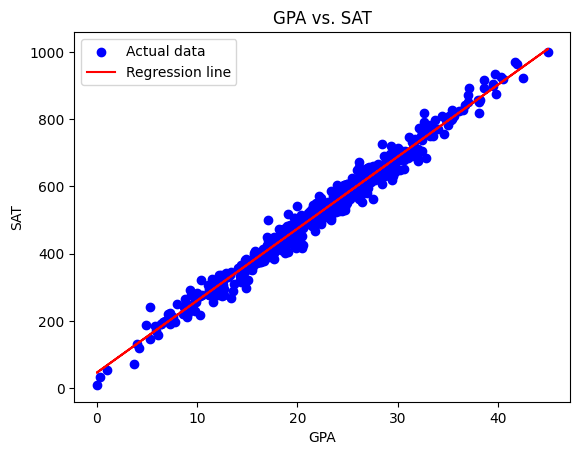

In [60]:
plt.scatter(X,y, color = 'blue', label ='Actual data')
plt.plot(X, model.predict(X), color = 'red', label ='Regression line')
plt.title('GPA vs. SAT')
plt.xlabel('GPA')
plt.ylabel('SAT')
plt.legend()
plt.show()

Que. 5
Following is the description of columns in dataset ToyotaCorolla.csv. Prepare a prediction model for predicting Price.



In [61]:
df = pd.read_csv('ToyotaCorolla.csv', encoding='latin1')

In [62]:
df.head()
df.tail()
df.info()
df.isna()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                1436 non-null   int64 
 1   Model             1436 non-null   object
 2   Price             1436 non-null   int64 
 3   Age_08_04         1436 non-null   int64 
 4   Mfg_Month         1436 non-null   int64 
 5   Mfg_Year          1436 non-null   int64 
 6   KM                1436 non-null   int64 
 7   Fuel_Type         1436 non-null   object
 8   HP                1436 non-null   int64 
 9   Met_Color         1436 non-null   int64 
 10  Color             1436 non-null   object
 11  Automatic         1436 non-null   int64 
 12  cc                1436 non-null   int64 
 13  Doors             1436 non-null   int64 
 14  Cylinders         1436 non-null   int64 
 15  Gears             1436 non-null   int64 
 16  Quarterly_Tax     1436 non-null   int64 
 17  Weight        

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,cc,...,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.580084,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.493717,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [63]:
features = ["Age_08_04", "KM", "HP", "cc", "Doors", "Gears", "Quarterly_Tax", "Weight"]
X = df[features]
y = df['Price']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [65]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [66]:
y_pred = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")


R-squared Score: 0.8538
Mean Squared Error: 1950244.99


Que. 6

Refer the “Engine.csv” and observe the dataset and decide type of Regression.
Datasets provide fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada.
Predict the Co2emission for with given fuel consumption ratings CYLINDERS, ENGINESIZE, FUELCONSUMPTION_COMB.

In [67]:
df = pd.read_csv('Engine.csv')

In [68]:
df.head()
df.tail()
df.info()
df.describe()
df.isna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ENGINESIZE            1067 non-null   float64
 1   CYLINDERS             1067 non-null   int64  
 2   FUELCONSUMPTION_COMB  1067 non-null   float64
 3   CO2EMISSIONS          1067 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 33.5 KB


,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
1062,False,False,False,False
1063,False,False,False,False
1064,False,False,False,False
1065,False,False,False,False


In [69]:
X = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = df['CO2EMISSIONS'] 


In [70]:
print(f"Rows in X: {X.shape[0]}") 
print(f"Rows in y: {len(y)}") 

Rows in X: 1067
Rows in y: 1067


In [71]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [72]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")


R-squared Score: 0.8760
Mean Squared Error: 512.86
